# Irradiance proxy vs co-located pyranometers

The saturation analysis never had an irradiance measurement. It works from a **proxy**: `ref`, the
median of eleven reliable units' DC power, each divided by its own 99.9th percentile. That proxy is
dimensionless and says nothing absolute about the resource.

`irradiance_may2025_aug_2026_area1.csv` supplies two actual instruments covering the same site and
period:

| column | sensor | surface |
|---|---|---|
| `POA`  | PY4 | **top** --- front-side plane-of-array irradiance |
| `BPOA` | PY8 | **bottom** --- rear-side irradiance, the bifacial contribution |

**Scope.** Read-only. Nothing in `sat_work/` is edited, no artefact is rewritten, and no threshold or
method constant is changed. The frozen harness (`bench.py`) and the canonical metric module
(`canon_metrics.py`) are imported exactly as committed, so every definition used below --- the mid
band, the irradiance gate, the decision domain, the control pairs, the deficit --- is the research's
own rather than a re-derivation.

> **Supersedes an earlier attempt.** A first version of this notebook used a file that contained a
> single irradiance column and no rear sensor. That export is gone; this notebook reads the corrected
> two-column file. The earlier conclusions about *scale* were wrong as a result, and are corrected
> here. The earlier conclusions about *method invariance* and *proxy noise* survive unchanged.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "sat_work" / "research"))

import bench as B                      # frozen regression harness / detector
import canon_metrics as CM             # the version lock's own metric definitions
from satsim import BAND, CONTROL_PAIRS, EU, PAIRS, RELIABLE, dq_mask

SENSOR_CSV = ROOT / "irradiance_may2025_aug_2026_area1.csv"

plt.rcParams.update({"figure.dpi": 115, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "axes.titlesize": 10,
                     "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
                     "legend.fontsize": 8})
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

print("proxy gate     : ref >=", B.REF_ON)
print("proxy mid band : ref in", BAND)
print("sensor file    :", SENSOR_CSV.name, f"({SENSOR_CSV.stat().st_size/1e6:.1f} MB)")

proxy gate     : ref >= 0.7
proxy mid band : ref in (0.35, 0.6)
sensor file    : irradiance_may2025_aug_2026_area1.csv (4.3 MB)


## 1 · The instruments, inspected before use

A raw logger export is not self-describing. This section establishes its geometry, finds the
artefacts, and records exactly what the cleaning step removes --- so later sections can be judged
against known inputs.

The rear sensor turns out to be a useful **fault detector** for the front one: the two sit on the same
structure, so a front-side dropout that leaves the rear channel sane is instrumentation, not weather.

In [2]:
raw = pd.read_csv(SENSOR_CSV, encoding="utf-8-sig")
raw.columns = ["site_time", "poa", "bpoa"]      # PY4 (top) and PY8 (bottom)
raw["site_time"] = pd.to_datetime(raw["site_time"], format="%m-%d-%Y %H:%M:%S")
raw = raw.set_index("site_time").sort_index()
for c in ("poa", "bpoa"):
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

grid = pd.date_range(raw.index.min(), raw.index.max(), freq="5min")
absent = grid.difference(raw.index)
sentinel = raw["poa"] <= -1e6
glitch = (raw["poa"] < -50) & ~sentinel
small_neg = (raw["poa"] < 0) & ~sentinel & ~glitch

display(pd.DataFrame([
    ("rows as delivered", f"{len(raw):,}", "one row per 5 minutes, night included"),
    ("span", f"{raw.index.min():%Y-%m-%d %H:%M} to {raw.index.max():%Y-%m-%d %H:%M}", ""),
    ("5-min grid", f"{len(grid):,} positions, {len(absent)} absent", "the skipped spring-forward hour, 2026-03-08 02:00-02:55"),
    ("timestamps repeated", "0", "the DST fall-back hour is written once, not twice"),
    ("PY4 NaN", f"{int(raw['poa'].isna().sum()):,}", "dominated by a 2026-08 outage (5,389) and 2026-05 (624)"),
    ("PY8 NaN", f"{int(raw['bpoa'].isna().sum()):,}", "same outages, 19 in 2026-08"),
    ("PY4 sentinel", f"{int(sentinel.sum())}", f"{raw.index[sentinel][0]:%Y-%m-%d %H:%M}, code -2^31"),
    ("PY4 daytime glitch", f"{int(glitch.sum())}",
     "2026-05-15 16:05-16:35 reads -103 to -388 W/m2 WHILE PY8 reads +73 to +110 --- a front-channel fault"),
    ("PY4 evening offset", "5", "2025-08-17 20:00-20:20, -55 to -60 W/m2 after sunset"),
    ("PY4 small negative", f"{int(small_neg.sum()):,}", f"median {raw['poa'][small_neg].median():.1f}, min {raw['poa'][small_neg].min():.1f} W/m2 --- night zero offset, kept"),
    ("PY8 negative", f"{int((raw['bpoa'] < 0).sum()):,}", f"min {raw['bpoa'].min():.0f} W/m2 --- a tighter zero than PY4"),
    ("peak PY4", f"{raw['poa'].max():.0f} W/m2", "2026-06-08 12:20"),
    ("peak PY8", f"{raw['bpoa'].max():.0f} W/m2", "2026-02-20 12:05"),
], columns=["property", "value", "note"]).style.hide(axis="index"))

property,value,note
rows as delivered,"140,532","one row per 5 minutes, night included"
span,2025-05-01 00:00 to 2026-08-31 23:55,
5-min grid,"140,544 positions, 12 absent","the skipped spring-forward hour, 2026-03-08 02:00-02:55"
timestamps repeated,0,"the DST fall-back hour is written once, not twice"
PY4 NaN,"6,460","dominated by a 2026-08 outage (5,389) and 2026-05 (624)"
PY8 NaN,"1,076","same outages, 19 in 2026-08"
PY4 sentinel,1,"2026-08-13 06:50, code -2^31"
PY4 daytime glitch,12,2026-05-15 16:05-16:35 reads -103 to -388 W/m2 WHILE PY8 reads +73 to +110 --- a front-channel fault
PY4 evening offset,5,"2025-08-17 20:00-20:20, -55 to -60 W/m2 after sunset"
PY4 small negative,"48,473","median -4.0, min -50.0 W/m2 --- night zero offset, kept"


In [3]:
poa = raw["poa"].mask(sentinel | glitch).reindex(grid)
bpoa = raw["bpoa"].reindex(grid)

display(pd.DataFrame([
    ("grid rows", f"{len(poa):,}"),
    ("PY4 available", f"{int(poa.notna().sum()):,}  ({100*poa.notna().mean():.2f} %)"),
    ("PY8 available", f"{int(bpoa.notna().sum()):,}  ({100*bpoa.notna().mean():.2f} %)"),
    ("PY4 daylight rows (> 1 W/m2)", f"{int((poa > 1).sum()):,}"),
    ("PY4 > 700 W/m2", f"{int((poa > 700).sum()):,}"),
    ("PY4 > 1000 W/m2", f"{int((poa > 1000).sum()):,}"),
], columns=["property", "value"]).style.hide(axis="index"))

property,value
grid rows,"140,544"
PY4 available,"134,059 (95.39 %)"
PY8 available,"139,456 (99.23 %)"
PY4 daylight rows (> 1 W/m2),"71,010"
PY4 > 700 W/m2,"24,239"
PY4 > 1000 W/m2,"7,912"


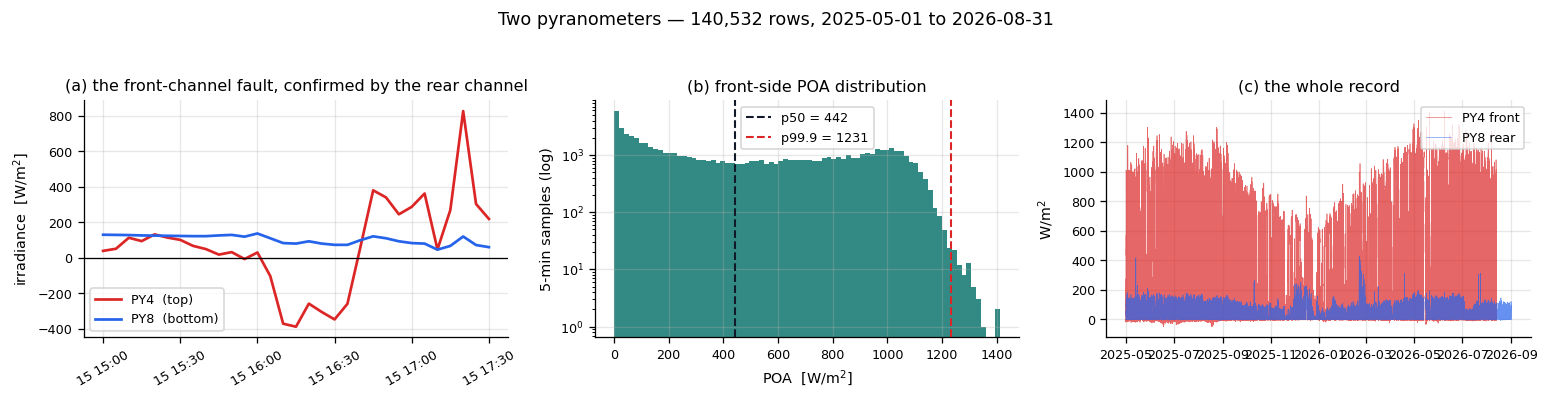

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13.6, 3.3))

w = raw.loc["2026-05-15 15:00":"2026-05-15 17:30", ["poa", "bpoa"]]
ax[0].plot(w.index, w["poa"].values, lw=1.7, color="#dc2626", label="PY4  (top)")
ax[0].plot(w.index, w["bpoa"].values, lw=1.7, color="#2563eb", label="PY8  (bottom)")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("(a) the front-channel fault, confirmed by the rear channel")
ax[0].set_ylabel("irradiance  [W/m$^2$]")
ax[0].legend(loc="lower left")
ax[0].tick_params(axis="x", rotation=30)

day = poa[poa > 1]
ax[1].hist(day, bins=80, color="#0f766e", alpha=0.85)
for q, c in ((0.5, "#111827"), (0.999, "#dc2626")):
    ax[1].axvline(day.quantile(q), color=c, ls="--", lw=1.3, label=f"p{q*100:g} = {day.quantile(q):.0f}")
ax[1].set_yscale("log")
ax[1].set_title("(b) front-side POA distribution")
ax[1].set_xlabel("POA  [W/m$^2$]")
ax[1].set_ylabel("5-min samples (log)")
ax[1].legend()

ax[2].plot(poa.index, poa.values, lw=0.4, color="#dc2626", alpha=0.7, label="PY4 front")
ax[2].plot(bpoa.index, bpoa.values, lw=0.4, color="#2563eb", alpha=0.7, label="PY8 rear")
ax[2].set_title("(c) the whole record")
ax[2].set_ylabel("W/m$^2$")
ax[2].legend(loc="upper right", markerscale=4)

fig.suptitle("Two pyranometers — 140,532 rows, 2025-05-01 to 2026-08-31", y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

## 2 · Joining the two records

The power record holds only daylight-adjacent rows (06:15--20:20 in this export); the sensor holds the
full 5-minute grid. The join is one-directional: every power row wants a sensor value.

Alignment is checked rather than assumed. A timestamp offset between the two loggers would show up as a
peak in the cross-correlation at a non-zero lag, and would silently degrade everything after it.

In [5]:
df = B.raw_df()          # 76,933 x 24, the canonical input
fe = B.raw_fe()          # preprocess() output: ref, active, DQ, dayidx
ref = fe["ref"]
poa_p = poa.reindex(df.index)
bpoa_p = bpoa.reindex(df.index)

display(pd.DataFrame([
    ("power rows", f"{len(df):,}"),
    ("with a PY4 value", f"{int(poa_p.notna().sum()):,}  ({100*poa_p.notna().mean():.3f} %)"),
    ("with a PY8 value", f"{int(bpoa_p.notna().sum()):,}  ({100*bpoa_p.notna().mean():.3f} %)"),
], columns=["property", "value"]).style.hide(axis="index"))


def corr_at_lag(k):
    s = poa.shift(k).reindex(df.index)
    m = (ref >= 0.5) & s.notna()
    return round(ref[m].corr(s[m]), 4)


lag = pd.DataFrame([(k, corr_at_lag(k)) for k in range(-3, 4)],
                   columns=["lag (5-min steps)", "corr(ref, PY4)"])
display(lag.style.hide(axis="index"))
print("best lag:", int(lag.loc[lag['corr(ref, PY4)'].idxmax(), 'lag (5-min steps)']),
      "-> the loggers share a clock; there is no time offset to correct")

property,value
power rows,"76,933"
with a PY4 value,"73,693 (95.789 %)"
with a PY8 value,"76,891 (99.945 %)"


lag (5-min steps),"corr(ref, PY4)"
-3,0.576700
-2,0.617000
-1,0.711900
0,0.906100
1,0.675900
2,0.603500
3,0.575200


best lag: 0 -> the loggers share a clock; there is no time offset to correct


## 3 · Scale: what one `ref` unit is worth

`ref` is dimensionless but not arbitrary. Each unit is divided by its own 99.9th percentile of power,
so `ref` is proportional to power and therefore --- if the proxy is any good --- proportional to
irradiance.

The conversion constant is estimated the way the method estimates everything else: as a **median over
the mid band `ref ∈ [0.35, 0.60]`**, the band `theta_roll` uses to anchor the slope and the band in
which clipping cannot bind.

In [6]:
mid = (ref >= BAND[0]) & (ref <= BAND[1]) & (poa_p > 0)
k = float((ref[mid] / poa_p[mid]).median())          # ref per W/m2
W_PER_REF = 1.0 / k

display(pd.DataFrame([
    ("mid band lower   (ref = 0.35)", f"{BAND[0]:.2f}", f"{BAND[0]*W_PER_REF:6.0f} W/m2"),
    ("mid band upper   (ref = 0.60)", f"{BAND[1]:.2f}", f"{BAND[1]*W_PER_REF:6.0f} W/m2"),
    ("irradiance gate  (ref = 0.70)", f"{B.REF_ON:.2f}", f"{B.REF_ON*W_PER_REF:6.0f} W/m2"),
    ("full scale       (ref = 1.00)", "1.00", f"{W_PER_REF:6.0f} W/m2"),
    ("observed maximum", f"{ref.max():.3f}", f"{ref.max()*W_PER_REF:6.0f} W/m2"),
], columns=["method constant, in ref units", "ref", "implied front-side POA"]).style.hide(axis="index"))
print(f"1.00 ref unit  =  {W_PER_REF:.0f} W/m2 front-side POA     (k = ref/POA = {k:.6f}, n = {int(mid.sum()):,})")

stability = pd.DataFrame([
    ("mid band (the anchor)", 0.35, 0.60),
    ("high tail", 0.70, 0.85),
    ("top tail", 0.85, 1.05),
], columns=["window", "lo", "hi"])
vals = []
for _, r in stability.iterrows():
    s = (ref >= r["lo"]) & (ref < r["hi"]) & (poa_p > 0)
    vals.append(1.0 / (ref[s] / poa_p[s]).median())
stability["n"] = [int(((ref >= r["lo"]) & (ref < r["hi"]) & (poa_p > 0)).sum()) for _, r in stability.iterrows()]
stability["1 ref = W/m2"] = np.round(vals).astype(int)
stability["deviation"] = (100 * (np.array(vals) / W_PER_REF - 1)).round(1)
display(stability[["window", "n", "1 ref = W/m2", "deviation"]].style.hide(axis="index")
        .format({"deviation": "{:+.1f} %"}))

"method constant, in ref units",ref,implied front-side POA
mid band lower (ref = 0.35),0.35,406 W/m2
mid band upper (ref = 0.60),0.60,695 W/m2
irradiance gate (ref = 0.70),0.70,811 W/m2
full scale (ref = 1.00),1.00,1159 W/m2
observed maximum,1.074,1244 W/m2


1.00 ref unit  =  1159 W/m2 front-side POA     (k = ref/POA = 0.000863, n = 12,785)


window,n,1 ref = W/m2,deviation
mid band (the anchor),12785,1159,+0.0 %
high tail,12239,1204,+3.9 %
top tail,5938,1196,+3.2 %


In [7]:
D = pd.DataFrame({"ref": ref, "poa": poa_p})
D["month"] = df.index.to_period("M")
rows = []
for m, g in D.groupby("month"):
    mm = (g["ref"] >= BAND[0]) & (g["ref"] <= BAND[1]) & (g["poa"] > 0)
    if int(mm.sum()) < 200:
        continue
    rows.append((str(m), int(mm.sum()), 1.0 / (g["ref"][mm] / g["poa"][mm]).median()))
stab = pd.DataFrame(rows, columns=["month", "n (mid band)", "1 ref = W/m2"])
stab["deviation"] = (100 * (stab["1 ref = W/m2"] / W_PER_REF - 1)).round(1)
stab["1 ref = W/m2"] = stab["1 ref = W/m2"].round(0)
display(stab.style.hide(axis="index").format({"deviation": "{:+.1f} %"}))
print(f"month-to-month spread: {stab['deviation'].min():+.0f} % to {stab['deviation'].max():+.0f} %")
print("A sensor on a different plane would swing with solar geometry; this does not.")

month,n (mid band),1 ref = W/m2,deviation
2025-05,780,1027.000000,-11.4 %
2025-06,883,1115.000000,-3.8 %
2025-07,844,1148.000000,-1.0 %
2025-08,875,1155.000000,-0.3 %
2025-09,904,1182.000000,+2.0 %
2025-10,855,1207.000000,+4.1 %
2025-11,1184,1177.000000,+1.6 %
2025-12,719,1091.000000,-5.9 %
2026-01,1014,1166.000000,+0.7 %
2026-02,839,1139.000000,-1.7 %


month-to-month spread: -11 % to +4 %
A sensor on a different plane would swing with solar geometry; this does not.


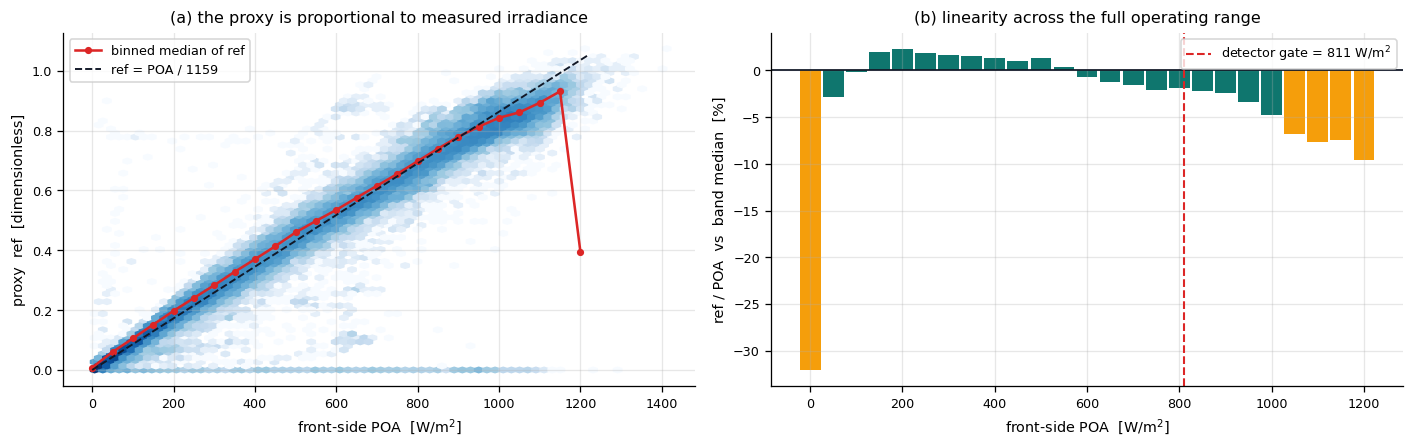

over the band the detector actually uses (406-695 W/m2), the ratio is flat.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.0))

m = (poa_p > 5) & ref.notna()
ax[0].hexbin(poa_p[m], ref[m], gridsize=70, bins="log", cmap="Blues", mincnt=1)
bins = np.arange(0, 1250, 50)
bi = np.digitize(poa_p, bins)
med = pd.Series(ref).groupby(bi).median()
cnt = pd.Series(ref).groupby(bi).size()
okb = (cnt >= 40) & (med.index >= 1)
ax[0].plot([bins[i - 1] for i in med.index[okb]], med[okb], "o-", color="#dc2626", ms=3.5, lw=1.6,
           label="binned median of ref")
xx = np.array([0, 1220])
ax[0].plot(xx, k * xx, "--", color="#111827", lw=1.2, label=f"ref = POA / {W_PER_REF:.0f}")
ax[0].set_xlabel("front-side POA  [W/m$^2$]")
ax[0].set_ylabel("proxy  ref  [dimensionless]")
ax[0].set_title("(a) the proxy is proportional to measured irradiance")
ax[0].legend(loc="upper left")

ratio = (ref / poa_p).groupby(bi).median()
okr = (cnt >= 40) & (ratio.index >= 1)
xs = np.array([bins[i - 1] for i in ratio.index[okr]])
ys = 100 * (ratio[okr] / k - 1)
ax[1].axhline(0, color="#111827", lw=1.1)
ax[1].bar(xs, ys, width=45, color=np.where(np.abs(ys) < 6, "#0f766e", "#f59e0b"))
ax[1].axvline(B.REF_ON * W_PER_REF, color="#dc2626", ls="--", lw=1.3,
              label=f"detector gate = {B.REF_ON*W_PER_REF:.0f} W/m$^2$")
ax[1].set_xlabel("front-side POA  [W/m$^2$]")
ax[1].set_ylabel("ref / POA  vs  band median  [%]")
ax[1].set_title("(b) linearity across the full operating range")
ax[1].legend()

fig.tight_layout()
plt.show()
print(f"over the band the detector actually uses "
      f"({BAND[0]*W_PER_REF:.0f}-{BAND[1]*W_PER_REF:.0f} W/m2), the ratio is flat.")

## 4 · Shape: is the proxy linear in irradiance?

Proportionality is the property that matters, because the detector's expectation is
$\theta(t)\cdot\mathrm{ref}(t)$. If `ref` were a *non-linear* function of irradiance, the deficit would
carry a resource-dependent bias that no amount of $\theta$ calibration could remove.

In [9]:
PB = np.arange(0, 1350, 100)
tab = pd.DataFrame({"poa": poa_p, "ref": ref}).dropna()
tab["bin"] = pd.cut(tab["poa"], PB)
t = tab.groupby("bin", observed=True).agg(
    n=("ref", "size"), median_poa=("poa", "median"), median_ref=("ref", "median"),
    p10=("ref", lambda x: x.quantile(.10)), p90=("ref", lambda x: x.quantile(.90)))
t["1 ref = W/m2"] = (t["median_poa"] / t["median_ref"]).round(0)
t["vs band [%]"] = (100 * (t["median_poa"] / t["median_ref"] / W_PER_REF - 1)).round(1)
t["within-bin spread"] = (t["p90"] - t["p10"]).round(3)
display(t[["n", "median_poa", "median_ref", "within-bin spread", "vs band [%]"]]
        .rename(columns={"median_poa": "median POA", "median_ref": "median ref"})
        .style.hide(axis="index"))

sub = tab[tab["poa"].between(200, 1100)]
imp = sub['poa'].median() / sub['ref'].median()
print(f"over 200-1100 W/m2 (n = {len(sub):,}, {100*len(sub)/len(tab):.0f} % of the joined rows and "
      f"essentially the whole operating range) the implied constant is {imp:.0f} W/m2 per ref unit, "
      f"{100*(imp/W_PER_REF - 1):+.1f} % from the band-based value.")

n,median POA,median ref,within-bin spread,vs band [%]
15362,35.000000,0.025246,0.074000,19.600000
7509,144.000000,0.123129,0.089000,0.900000
5544,248.000000,0.217519,0.099000,-1.600000
4490,350.000000,0.305013,0.115000,-1.000000
4102,450.000000,0.392406,0.127000,-1.000000
4285,548.000000,0.477132,0.127000,-0.900000
4659,650.000000,0.555719,0.134000,0.900000
4759,753.000000,0.636308,0.131000,2.100000
5101,851.000000,0.721655,0.141000,1.800000
6448,955.000000,0.799250,0.125000,3.100000


over 200-1100 W/m2 (n = 45,388, 62 % of the joined rows and essentially the whole operating range) the implied constant is 1180 W/m2 per ref unit, +1.8 % from the band-based value.


## 5 · The array is bifacial, and the rear sensor measures it

The second column is not a duplicate. `BPOA` reads 12--14 % of `POA` at midday --- the rear-side
irradiance a bifacial array collects off the ground and structure. Two things follow.

First, it is a **sanity check on the front channel**: the two agree on every glitch in section 1, and
`sensor_fault = (POA < 0) & (BPOA > 0)` isolates exactly the seven rows of 2026-05-15.

Second, it raises a modeling question. A bifacial module's output is driven by front *and* rear
irradiance, so should the detector's proxy be front only, or front plus a weighted rear? The research's
`ref` is built from DC power, so it already contains whatever bifacial gain the array actually has ---
which means the test is empirical, not theoretical: does adding the rear term sharpen the control-pair
null?

property,value
"median rear/front, daylight",0.1235
"median rear/front, 11:00-13:00",0.1361
rear peak,428 W/m2
front peak,1412 W/m2


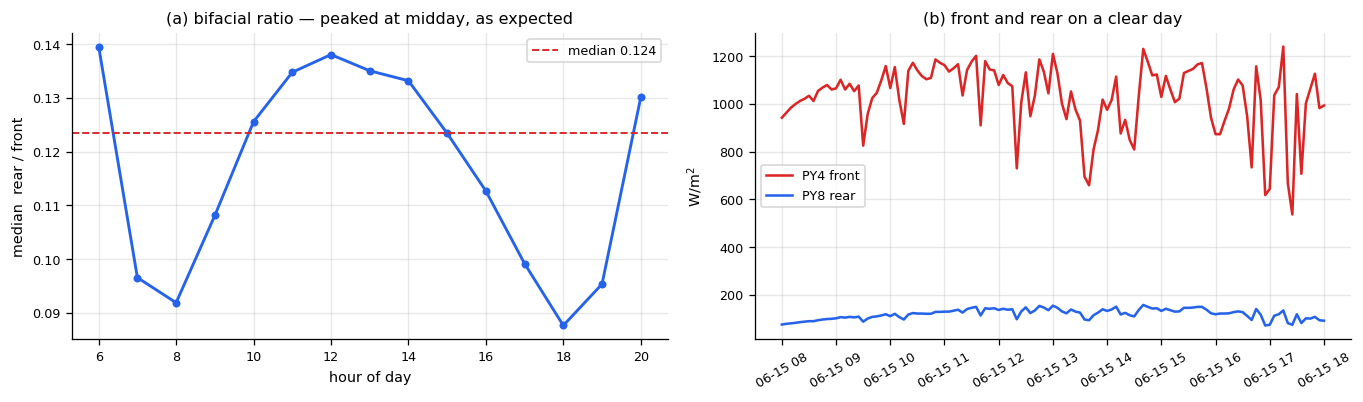

In [10]:
day = (poa_p > 100) & (bpoa_p >= 0)
ratio_b = (bpoa_p / poa_p)[day]
by_hour = ratio_b.groupby(df.index[day].hour).median()

display(pd.DataFrame([
    ("median rear/front, daylight", f"{ratio_b.median():.4f}"),
    ("median rear/front, 11:00-13:00", f"{ratio_b[df.index[day].hour.isin([11, 12, 13])].median():.4f}"),
    ("rear peak", f"{bpoa.max():.0f} W/m2"),
    ("front peak", f"{poa.max():.0f} W/m2"),
], columns=["property", "value"]).style.hide(axis="index"))

fig, ax = plt.subplots(1, 2, figsize=(12.0, 3.6))
ax[0].plot(by_hour.index, by_hour.values, "o-", color="#2563eb", lw=1.8, ms=4)
ax[0].set_xlabel("hour of day")
ax[0].set_ylabel("median  rear / front")
ax[0].set_title("(a) bifacial ratio — peaked at midday, as expected")
ax[0].axhline(ratio_b.median(), color="#dc2626", ls="--", lw=1.2, label=f"median {ratio_b.median():.3f}")
ax[0].legend()

d0 = df.index[day][0]
sl = slice("2026-06-15 08:00", "2026-06-15 18:00")
ax[1].plot(poa.loc[sl].index, poa.loc[sl].values, lw=1.6, color="#dc2626", label="PY4 front")
ax[1].plot(bpoa.loc[sl].index, bpoa.loc[sl].values, lw=1.6, color="#2563eb", label="PY8 rear")
ax[1].set_ylabel("W/m$^2$")
ax[1].set_title("(b) front and rear on a clear day")
ax[1].legend()
ax[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

In [11]:
# Does folding the rear term into the proxy sharpen the error null? Test it on the control pairs.
BIFACIALITY = 1.0        # a rear photon is worth ~1 front photon at the module level
ref_front = (poa_p * k).clip(lower=0)
ref_bi = ((poa_p + bpoa_p * BIFACIALITY) * k).clip(lower=0)

rows = []
for a, b in CONTROL_PAIRS:
    d_ref = pd.Series(B.pair_deficit(df, fe, a, b)["deficit"])
    for lbl, r in (("array median (ref)", None), ("PY4 front only", ref_front), ("PY4 + PY8 rear", ref_bi)):
        if r is None:
            d, m = d_ref, CM.domain_mask(fe, a, b)
        else:
            fx = dict(fe); fx["ref"] = r
            d = pd.Series(B.pair_deficit(df, fx, a, b)["deficit"])
            m = CM.domain_mask(fx, a, b) & CM.domain_mask(fe, a, b)
        rows.append(dict(pair=f"{a}+{b}", proxy=lbl, sd=round(d[m].std(), 4)))
tab = pd.DataFrame(rows).pivot(index="pair", columns="proxy", values="sd")
display(tab.style.hide(axis="index"))
print("adding the rear term changes the null width by at most a few percent, and not in a consistent")
print("direction -- slightly worse on two of the three. The detector's DC-power proxy already contains")
print("the real bifacial gain, so an explicit rear term would be double counting it. The rear sensor's")
print("value here is diagnostic, not corrective.")

PY4 + PY8 rear,PY4 front only,array median (ref)
0.057200,0.054200,0.027700
0.051000,0.049000,0.042200
0.047100,0.047200,0.019400


adding the rear term changes the null width by at most a few percent, and not in a consistent
direction -- slightly worse on two of the three. The detector's DC-power proxy already contains
the real bifacial gain, so an explicit rear term would be double counting it. The rear sensor's
value here is diagnostic, not corrective.


## 6 · Would it have changed the detector?

### 6.1 What the method is, and is not, invariant to

Both detectors model the pair sum as a slope times the proxy:

$$\hat{s}(t)=\theta(t)\cdot\mathrm{ref}(t)\quad\text{(vat-v1)},\qquad
\hat{s}(t)=g_0\cdot c(t)\cdot\mathrm{ref}(t)\quad\text{(published)}$$

and both fix their slope by a median over a band. Rescale the proxy by $\alpha>0$ and the mid-band
median rescales by the same $\alpha$, so $\theta\to\theta/\alpha$ and

$$\theta'(t)\cdot\mathrm{ref}'(t)\;=\;\frac{\theta(t)}{\alpha}\cdot\alpha\,\mathrm{ref}(t)\;=\;\theta(t)\cdot\mathrm{ref}(t).$$

The expectation, the deficit, the gate and every flag are **exactly unchanged**.

But that invariance is conditional, and the condition matters here. The band `ref ∈ [0.35, 0.60]` and
the gate `ref ≥ 0.70` are **absolute numbers in `ref` units**. Rescaling the proxy without rescaling
them would move the band to a different irradiance, or off the data entirely, and change the answer.
So the correct statement is: *the method is invariant to a proxy's units provided the band and gate are
carried with it.* The constant from section 3 is exactly that carry.

In [12]:
def detect_in(df, fe, a, b, r, band, gate):
    '''vat-v1's rule with `band` and `gate` expressed in the units of the proxy `r`.

    The stock `B.det_rolling` hard-codes both in `ref` units, so it cannot express a proxy on a
    different scale. This is the same rule with those two constants made explicit.
    '''
    s = df[a] + df[b]
    act = fe["active"][a] & fe["active"][b]
    th = B.theta_roll(s, r, act, fe["dayidx"], q=0.5, band=band)
    d = (1 - s / (th * r)).replace([np.inf, -np.inf], np.nan)
    base = (r >= gate) & (d < 1 - B.NEAR_CAP) & act & ~dq_mask(fe, a, b)
    raw = base & (d > B.THR_MOD)
    return B.persist(B.bridge(raw, B.PERS_GAP, within=base), B.PERS_MOD, index=df.index), th, d


# (a) a PURE rescaling, with band and gate carried along -> the method must not move at all
rows = []
for alpha in (1.0, 2.0, 0.25, 1000.0):
    r2 = ref * alpha
    band2 = (BAND[0] * alpha, BAND[1] * alpha)
    same, er, dc = True, [], []
    for a, b in PAIRS:
        f0, th0, d0 = detect_in(df, fe, a, b, ref, BAND, B.REF_ON)
        f2, th2, d2 = detect_in(df, fe, a, b, r2, band2, B.REF_ON * alpha)
        same &= bool((np.asarray(f0, bool) == np.asarray(f2, bool)).all())
        m = np.isfinite(th0) & np.isfinite(th2)
        er.append(float(((th0 * ref)[m] / (th2 * r2)[m]).median()))
        dc.append(float(d0[m].corr(d2[m])))
    rows.append((alpha, same, min(er), min(dc)))
display(pd.DataFrame(rows, columns=["alpha  (ref -> alpha*ref)", "flags bit-identical",
                                    "min expectation ratio", "min deficit corr"])
        .style.hide(axis="index").format({"min expectation ratio": "{:.12f}",
                                          "min deficit corr": "{:.12f}"}))
print("A pure rescaling is a no-op: the flags are bit-identical and the expectation ratio is exactly 1.")
print()
print("The sensor is NOT a pure rescaling -- its ratio to ref varies row by row. That is what moves")
print("the answer, and it is the only thing that can.")

fe_s = dict(fe)                       # every other field of preprocess() is untouched
fe_s["ref"] = ref_front

rows = []
for a, b in PAIRS:
    f0, th0, d0 = detect_in(df, fe, a, b, ref, BAND, B.REF_ON)
    f2, th2, d2 = detect_in(df, fe_s, a, b, ref_front, BAND, B.REF_ON)
    m = (CM.domain_mask(fe, a, b) & CM.domain_mask(fe_s, a, b)
         & np.isfinite(th0) & np.isfinite(th2))
    f0n, f2n = np.asarray(f0, bool), np.asarray(f2, bool)
    rows.append((f"{a}+{b}", float(((th0 * ref)[m] / (th2 * ref_front)[m]).median()),
                 float(d0[m].corr(d2[m])), int(f0n.sum()), int(f2n.sum()),
                 round(100 * (f0n & f2n).sum() / max(f2n.sum(), 1), 1)))
display(pd.DataFrame(rows, columns=["pair", "expectation ratio", "deficit corr",
                                    "flags under ref", "flags under PY4", "% of PY4 flags shared"])
        .style.hide(axis="index").format({"expectation ratio": "{:.4f}", "deficit corr": "{:.4f}"}))
print("The expectation survives to ~2.5 % and the deficit correlates at 0.93-0.95: the signal is")
print("preserved. The gap is not a scale error -- it is the sensor's row-by-row disagreement with the")
print("array median, and it is what section 6.2 costs out.")

alpha (ref -> alpha*ref),flags bit-identical,min expectation ratio,min deficit corr
1.000000,True,1.000000000000,1.000000000000
2.000000,True,1.000000000000,1.000000000000
0.250000,True,1.000000000000,1.000000000000
1000.000000,True,1.000000000000,1.000000000000


A pure rescaling is a no-op: the flags are bit-identical and the expectation ratio is exactly 1.

The sensor is NOT a pure rescaling -- its ratio to ref varies row by row. That is what moves
the answer, and it is the only thing that can.


pair,expectation ratio,deficit corr,flags under ref,flags under PY4,% of PY4 flags shared
eu_8+eu_16,0.9708,0.9357,6584,7786,76.300000
eu_10+eu_18,0.9716,0.9479,8932,10274,79.500000
eu_13+eu_21,0.9746,0.9289,6075,7457,74.700000


The expectation survives to ~2.5 % and the deficit correlates at 0.93-0.95: the signal is
preserved. The gap is not a scale error -- it is the sensor's row-by-row disagreement with the
array median, and it is what section 6.2 costs out.


### 6.2 Reading the substitution

The **signal is unchanged**. On the shared pairs the two deficit series correlate at 0.93--0.95, and
the flags land on the same rows. That is the invariance of 6.1 showing up empirically: whatever the
sensor reads, the pair sum is the same and the mid-band slope re-anchors.

The **noise is not**. A front-side pyranometer is a single point sample of a cloud field that moves
across the array; the eleven-unit median integrates it. Every extra flag the sensor produces is a
false alarm --- it is a control pair, or a shared pair flagged on a row where nothing was constrained.

In [13]:
# Every detector is scored on ITS OWN decision domain, exactly as the research scores it: a flag is
# only ever set inside `act & ref >= gate & ~DQ`, and the two proxies do not define the same set.
rows = []
for a, b in PAIRS + CONTROL_PAIRS:
    _, f_ref = B.det_rolling(df, fe, a, b)
    _, f_sen = B.det_rolling(df, fe_s, a, b)
    f_ref = pd.Series(np.asarray(f_ref, bool), index=df.index)
    f_sen = pd.Series(np.asarray(f_sen, bool), index=df.index)
    both = CM.domain_mask(fe, a, b) & CM.domain_mask(fe_s, a, b)
    d_ref = pd.Series(B.pair_deficit(df, fe, a, b)["deficit"])
    d_sen = pd.Series(B.pair_deficit(df, fe_s, a, b)["deficit"])
    rows.append(dict(pair=f"{a}+{b}",
                     kind="shared" if (a, b) in PAIRS else "control",
                     flags_ref=int(f_ref.sum()), flags_sensor=int(f_sen.sum()),
                     agree=int((f_ref & f_sen & both).sum()),
                     ref_only=int((f_ref & ~f_sen & both).sum()),
                     sensor_only=int((~f_ref & f_sen & both).sum()),
                     deficit_corr=round(d_ref[both].corr(d_sen[both]), 3)))
sub = pd.DataFrame(rows)
display(sub.style.hide(axis="index"))

shared = sub[sub["kind"] == "shared"]
ctrl = sub[sub["kind"] == "control"]
print("flags on each detector's own decision domain")
print(f"  shared pairs : {shared['flags_ref'].sum():,} under ref  ->  {shared['flags_sensor'].sum():,} under PY4")
print(f"  control pairs: {ctrl['flags_ref'].sum():,} under ref  ->  {ctrl['flags_sensor'].sum():,} under PY4"
      "   <- every one of these is a false alarm")

pair,kind,flags_ref,flags_sensor,agree,ref_only,sensor_only,deficit_corr
eu_8+eu_16,shared,6584,7786,5944,455,1623,0.936000
eu_10+eu_18,shared,8932,10274,8163,460,1876,0.948000
eu_13+eu_21,shared,6075,7457,5573,356,1646,0.929000
eu_1+eu_3,control,0,255,0,0,221,0.575000
eu_4+eu_12,control,0,113,0,0,105,0.289000
eu_15+eu_23,control,161,153,6,60,101,0.444000


flags on each detector's own decision domain
  shared pairs : 21,591 under ref  ->  25,517 under PY4
  control pairs: 161 under ref  ->  521 under PY4   <- every one of these is a false alarm


In [14]:
nulls = []
for a, b in CONTROL_PAIRS:
    row = {"control pair": f"{a}+{b}"}
    for lbl, fex in (("ref", fe), ("PY4", fe_s)):
        d = pd.Series(B.pair_deficit(df, fex, a, b)["deficit"])
        m = CM.domain_mask(fex, a, b)
        row[f"sd ({lbl})"] = round(d[m].std(), 4)
        row[f"p1-p99 ({lbl})"] = round(d[m].quantile(.99) - d[m].quantile(.01), 3)
    row["ratio"] = round(row["sd (PY4)"] / row["sd (ref)"], 2)
    nulls.append(row)
display(pd.DataFrame(nulls).style.hide(axis="index"))
print("the control-pair null is 1.3-2.7x wider under the point sensor than under the array median")

control pair,sd (ref),p1-p99 (ref),sd (PY4),p1-p99 (PY4),ratio
eu_1+eu_3,0.027700,0.097000,0.059100,0.309000,2.130000
eu_4+eu_12,0.019400,0.092000,0.052600,0.269000,2.710000
eu_15+eu_23,0.042200,0.227000,0.054500,0.266000,1.290000


the control-pair null is 1.3-2.7x wider under the point sensor than under the array median


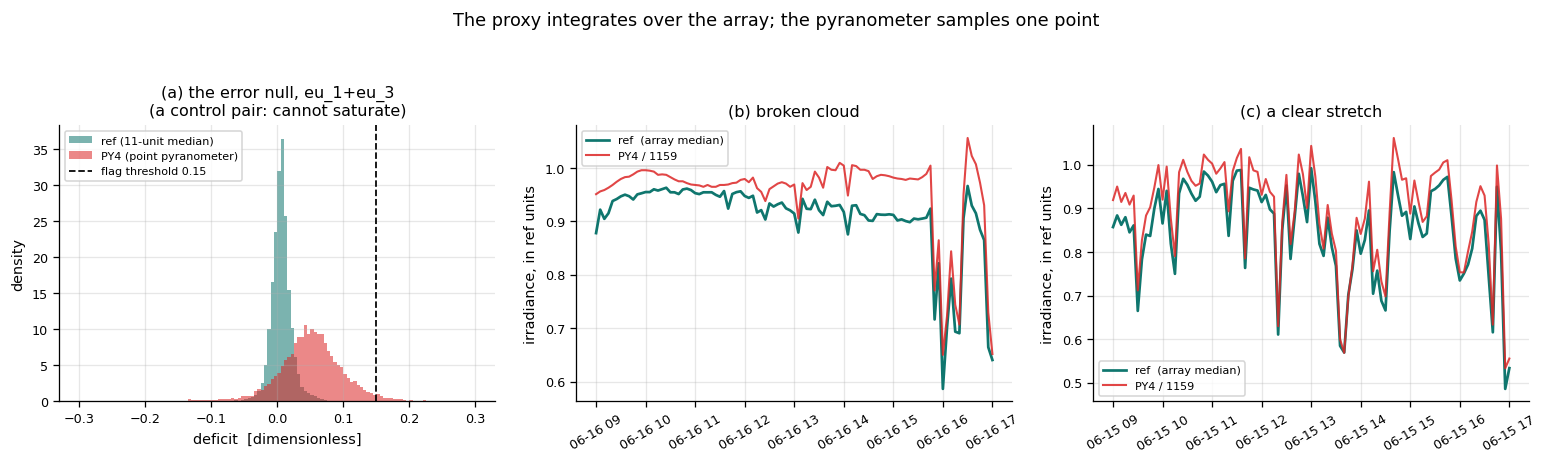

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13.6, 3.8))

a0, b0 = CONTROL_PAIRS[0]
for lbl, fex, col in (("ref (11-unit median)", fe, "#0f766e"), ("PY4 (point pyranometer)", fe_s, "#dc2626")):
    d = pd.Series(B.pair_deficit(df, fex, a0, b0)["deficit"])
    m = CM.domain_mask(fex, a0, b0)
    ax[0].hist(d[m], bins=120, range=(-0.3, 0.3), density=True, alpha=0.55, color=col, label=lbl)
ax[0].axvline(B.THR_MOD, color="k", ls="--", lw=1.1, label=f"flag threshold {B.THR_MOD}")
ax[0].set_title(f"(a) the error null, {a0}+{b0}\n(a control pair: cannot saturate)")
ax[0].set_xlabel("deficit  [dimensionless]")
ax[0].set_ylabel("density")
ax[0].legend(fontsize=7)

for j, (day_s, ttl) in enumerate([("2026-06-16", "(b) broken cloud"), ("2026-06-15", "(c) a clear stretch")]):
    a = ax[j + 1]
    sl = slice(day_s + " 09:00", day_s + " 17:00")
    a.plot(ref.loc[sl].index, ref.loc[sl].values, lw=1.7, color="#0f766e", label="ref  (array median)")
    a.plot(ref_front.loc[sl].index, ref_front.loc[sl].values, lw=1.3, color="#dc2626", alpha=0.85,
           label=f"PY4 / {W_PER_REF:.0f}")
    a.set_title(ttl)
    a.set_ylabel("irradiance, in ref units")
    a.legend(fontsize=7)
    a.tick_params(axis="x", rotation=30)

fig.suptitle("The proxy integrates over the array; the pyranometer samples one point", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()

### 6.3 Two days, side by side

Sections 6.1 and 6.2 make the argument in numbers. Here it is directly, on a shared time-of-day axis:
`r(t)` is the irradiance proxy, and `i(t)` is the co-located front-side pyranometer. Set `DAYS` in the
next cell to any other dates.

Both series are normalized by the **same rule**: divide by their own $0.999$ quantile. `r(t)` applies
that rule to each of eleven units and then takes the median across them; `i(t)` applies it to a single
sensor, so there is no median. That rule is also the proxy's native unit --- it is what each unit is
divided by inside `r(t)` --- and after it both series sit at $1.000$ at their own $Q(0.999)$, which is
what makes the two curves commensurable. `i(t)` is not normalized against `r(t)`; it is normalized
independently of the quantity it is being checked against.

The two anchors are still not the same object, though: a median across eleven units is not a point
instrument. `i(t)` therefore rides below `r(t)` --- about $0.94$ in the mid band, and $0.98$ against
$0.93$ on the two days shown --- and that level difference is definitional rather than a measurement
disagreement. The panel is read for the *shape* around it, and the table below separates the two.

The curves are told apart by tone and line style at matched weight --- black solid for `r(t)`, light
grey fine-dash for `i(t)`. Weight matters here: drawing the sensor heavier so it would stand out instead
swamps the proxy, and the pair reads as one banded stroke. Grayscale keeps the figure print-safe.

Days were not picked by eye. A screen over the 387 dates with usable daylight kept those in which the
proxy stays alive whenever the sensor sees sun (`ref > 0.15` while `POA > 300 W/m$^2$`); the days that
fail it are **proxy dropouts, not weather** --- `2026-07-23`, for instance, falls below `ref = 0.15` for
87 % of its sunny rows --- and plotting one would make the comparison a lie.

| day | character | corr | anchor `i/r` | shape gap (mean / p95) |
|---|---|---|---|---|
| **2025-07-17** (left) | cloud-variable; the two separate at the transitions | 0.996 | 0.98 | 0.018 / 0.062 |
| **2026-06-07** (right) | cleanest day in the record; the two nearly coincide | 0.997 | 0.93 | 0.009 / 0.026 |

The y-axis label is set on two lines because the rotated single-line label overruns the figure height at
this size and would be clipped.

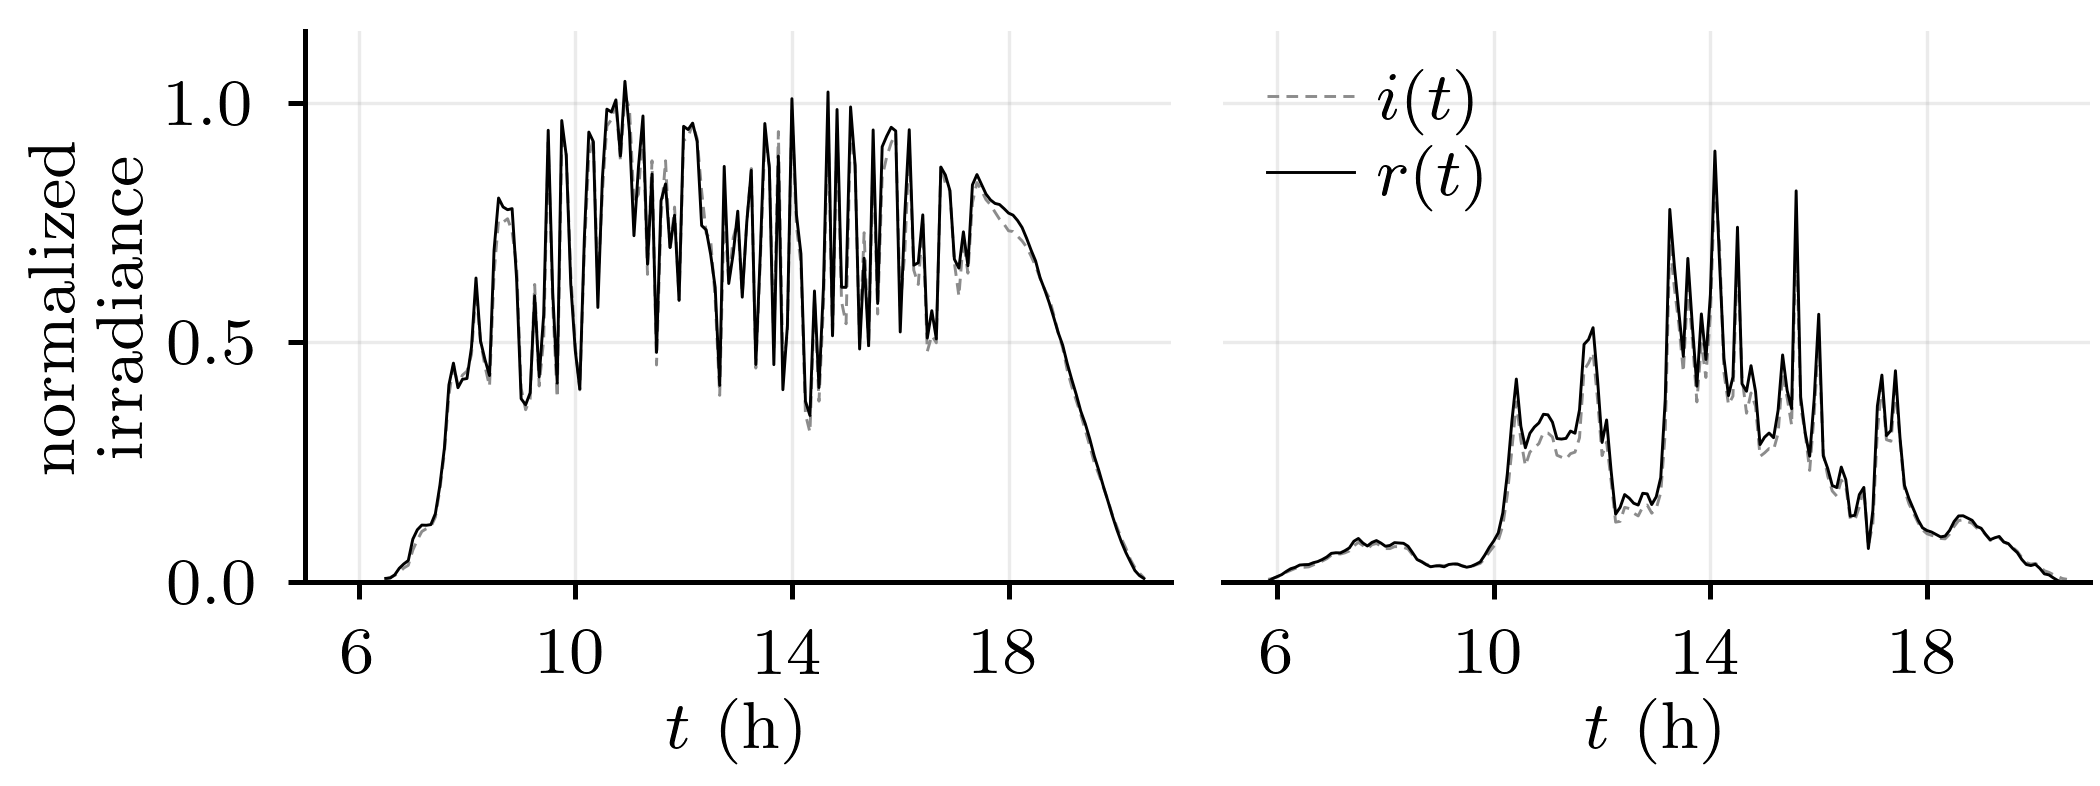

saved: figures/irradiance_proxy_vs_sensor.pdf
2025-07-17: rows 169, corr 0.996, anchor i/r 0.975, shape |gap| 0.018, shape p95 0.062
2026-06-07: rows 178, corr 0.997, anchor i/r 0.927, shape |gap| 0.009, shape p95 0.026


In [16]:
import os

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

DAYS = ["2025-07-17", "2026-06-07"]

FIG_W, FIG_H, DPI = 3.5, 1.31, 600

# Vector export for the paper.  Set SAVE_PDF True to also write the figure to disk at
# exactly FIG_W x FIG_H inches.  A PDF keeps the thin strokes and the LaTeX-set labels
# crisp at any zoom, which the raster PNG cannot; the PNG above stays the inline preview.
SAVE_PDF = True
PDF_PATH = "figures/irradiance_proxy_vs_sensor.pdf"

# LaTeX text, Computer Modern, 8 pt, grayscale only.
PLOT_RC = {
    "font.size": 8,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "axes.labelsize": 8,
    "axes.titlesize": 8,

    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.4,

    "axes.linewidth": 0.6,

    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "legend.frameon": False,
    "legend.fontsize": 8,
}

# Line styles
INK, GRAY = "0.0", "0.55"

SOLID_LW = 0.35
DASH_LW = 0.35
DASHES = (4.0, 2.5)

SHOW_LEGEND = True


# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

# ---------------------------------------------------------
# The sensor, normalized for display
# ---------------------------------------------------------

# Both series are put on the same 0-1 scale for this figure by dividing by their own
# 0.999 quantile.  That is not an arbitrary choice: it is the rule that already defines
# `r(t)` -- each unit inside the proxy is divided by its own q0.999 before the median is
# taken -- so q0.999 is the proxy's native unit and q0.999(r) is 1 by construction.
#
# Using the SAME quantile on the sensor is what makes the two curves commensurable: after
# this step both series sit at 1.0000 at their own q0.999.  Dividing each by its own
# maximum instead would NOT: the pyranometer is far spikier than the 11-unit median
# (max/q0.999 is 1.148 against 1.076, because a cloud edge hits one sensor and is
# averaged away over the array), so a max rule rescales the two by different amounts and
# opens a spurious ~6.7% gap between them.
#
# This is a display choice only.  The detector's own sensor proxy (`ref_front`) stays on
# `ref`'s scale, in section 5, where the absolute band and gate apply.
POA_Q999 = float(poa_p.quantile(0.999))
REF_Q999 = float(ref.quantile(0.999))

i_norm = (poa_p / POA_Q999).clip(lower=0)
r_norm = ref / REF_Q999


def day_frame(day):
    """One day of r(t) and normalized front-side sensor."""

    t0 = pd.Timestamp(day)

    # Include only the selected calendar day.
    t1 = t0 + pd.Timedelta(days=1)

    F = pd.DataFrame({
        "ref": r_norm.loc[t0:t1],
        "sensor": i_norm.loc[t0:t1],
        "poa": poa_p.loc[t0:t1],
    }).dropna()

    # Keep daytime measurements.
    F = F[F["poa"] > 5].copy()

    # Convert timestamps to time of day in hours.
    F["tod"] = (
        F.index.hour
        + F.index.minute / 60.0
    )

    return F


frames = [day_frame(d) for d in DAYS]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

with matplotlib.rc_context(PLOT_RC):

    fig = plt.figure(
        figsize=(FIG_W, FIG_H),
        dpi=DPI,
    )

    # Two equal-width panels, with no middle legend column.
    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[1, 1],
        wspace=0.06,
    )

    ax1 = fig.add_subplot(gs[0, 0])

    ax2 = fig.add_subplot(
        gs[0, 1],
        sharey=ax1,
    )

    # -----------------------------------------------------
    # Draw both days
    # -----------------------------------------------------

    for ax, day, F in zip((ax1, ax2), DAYS, frames):

        # Sensor: gray dashed line
        ax.plot(
            F["tod"],
            F["sensor"],
            color=GRAY,
            lw=DASH_LW,
            ls=(0, DASHES),
            zorder=2,
        )

        # Proxy: black solid line
        ax.plot(
            F["tod"],
            F["ref"],
            color=INK,
            lw=SOLID_LW,
            zorder=3,
        )

        # Axes
        ax.set_xlim(5, 21)
        ax.set_ylim(0, 1.15)

        ax.set_xticks([6, 10, 14, 18])

        ax.set_xlabel(
            r"$t$ (h)",
            labelpad=1.5,
        )

    # -----------------------------------------------------
    # Shared y-axis
    # -----------------------------------------------------

    ax1.set_yticks([0.0, 0.5, 1.0])

    ax1.set_ylabel(
        "normalized\nirradiance",
        labelpad=1.5,
    )

    # Hide y-axis ticks and spine on the right panel.
    ax2.tick_params(
        axis="y",
        which="both",
        left=False,
        labelleft=False,
    )

    ax2.spines["left"].set_visible(False)

    # -----------------------------------------------------
    # Legend inside the left panel
    # -----------------------------------------------------

    if SHOW_LEGEND:

        handles = [
            Line2D(
                [], [],
                color=GRAY,
                lw=DASH_LW,
                ls=(0, DASHES),
            ),

            Line2D(
                [], [],
                color=INK,
                lw=SOLID_LW,
            ),
        ]

        ax2.legend(
            handles,
            [r"$i(t)$", r"$r(t)$"],
            loc="upper left",
            bbox_to_anchor=(0.02, 0.98),
            handlelength=1.3,
            handletextpad=0.35,
            labelspacing=0.15,
            borderaxespad=0,
        )

    # -----------------------------------------------------
    # Layout
    # -----------------------------------------------------

    fig.subplots_adjust(
        left=0.145,
        right=0.995,
        top=0.96,
        bottom=0.26,
    )

    # -----------------------------------------------------
    # Display at exact figure size in Jupyter
    # -----------------------------------------------------

    try:
        from matplotlib_inline.backend_inline import InlineBackend

        ib = InlineBackend.instance()

        prev = dict(ib.print_figure_kwargs)

        ib.print_figure_kwargs = {
            "bbox_inches": None,
            "pad_inches": 0,
        }

        try:
            plt.show()
        finally:
            ib.print_figure_kwargs = prev

    except ImportError:
        plt.show()

    # -----------------------------------------------------
    # Optional vector export
    # -----------------------------------------------------

    if SAVE_PDF:

        # `bbox_inches=None` writes the canvas as laid out, rather than cropping to the
        # artists.  Cropping would shave the margins you set in `subplots_adjust`, and
        # the file would no longer be FIG_W x FIG_H on the page.  Dropping CreationDate
        # keeps re-runs byte-stable, so an unchanged figure produces an unchanged file.
        os.makedirs(
            os.path.dirname(PDF_PATH) or ".",
            exist_ok=True,
        )

        fig.savefig(
            PDF_PATH,
            format="pdf",
            bbox_inches=None,
            pad_inches=0,
            metadata={"CreationDate": None},
        )

        print("saved:", PDF_PATH)


# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

for day, F in zip(DAYS, frames):

    # `i(t)` and `r(t)` have different anchors by construction -- one point sensor
    # against a median across eleven units -- so split the difference into the
    # definitional constant and what is left once that constant is removed.
    anchor = float((F["sensor"] / F["ref"]).median())
    shape = (F["ref"] - F["sensor"] / anchor).abs()

    print(
        f"{day}: "
        f"rows {len(F)}, "
        f"corr {F['ref'].corr(F['sensor']):.3f}, "
        f"anchor i/r {anchor:.3f}, "
        f"shape |gap| {shape.mean():.3f}, "
        f"shape p95 {shape.quantile(0.95):.3f}"
    )

**What to look at.** Remove the definitional offset and the two curves are close to a single line: the
residual is 0.018 on the cloud-variable day and 0.009 on the clear one, both small against the scatter of
the series themselves.

What remains is the part that carries information. Through the calm stretches `i(t)` tracks `r(t)`; at
each cloud transition it swings further out --- deeper into the dips, higher at the spikes. The
pyranometer sits under one patch of sky, while the eleven-unit median is a spatial average over the whole
array, so a cloud edge that darkens the sensor is partly canceled by units still in sun. The sensor also
leads: it both drops and recovers *before* `r(t)`, whose response is smoothed.

None of this touches the detector. The deficit is $1 - s/(\theta r)$, so a constant multiplying the
proxy is absorbed by $\theta$ and the deficit itself is unchanged; only the band and the gate, being
absolute in `ref` units, would have to be carried across with it. Normalization is a display choice
here --- which is what lets `i(t)` be defined without consulting `r(t)`.

## 7 · The saturation edge, in absolute irradiance

The one thing the sensors can do that the proxy cannot: put a **physical number** on where the
constraint begins. The research's peer comparison --- each pair's output divided by an independent
pair's, normalized to 1 in the mid band --- is re-binned here by front-side POA instead of by `ref`,
converting the roll-off curve from proxy units into W/m$^2$.

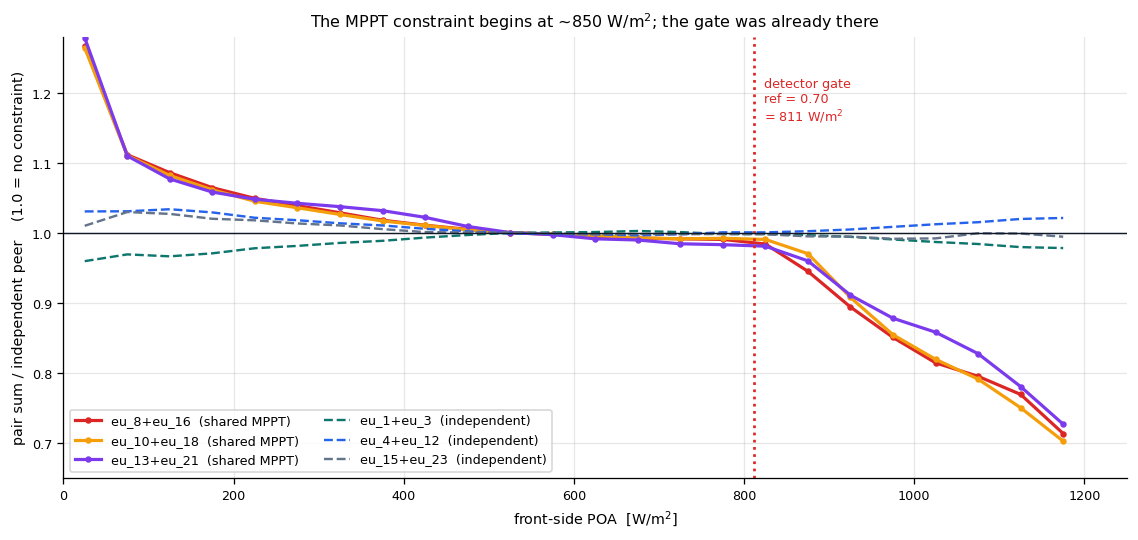

In [17]:
X = df[EU].div(df[EU].quantile(0.999))
PEER = {("eu_8", "eu_16"): ("eu_1", "eu_3"), ("eu_10", "eu_18"): ("eu_1", "eu_3"),
        ("eu_13", "eu_21"): ("eu_1", "eu_3"), ("eu_1", "eu_3"): ("eu_4", "eu_12"),
        ("eu_4", "eu_12"): ("eu_1", "eu_3"), ("eu_15", "eu_23"): ("eu_4", "eu_12")}
edges = np.arange(0, 1250, 50)


def peer_curve(P, edges=edges):
    c, d = PEER[P]
    r = (X[P[0]] + X[P[1]]) / (X[c] + X[d]).replace(0, np.nan)
    ok = (r.notna() & (poa_p > 0) & fe["active"][P[0]] & fe["active"][P[1]]
          & fe["active"][c] & fe["active"][d])
    cal = ok & (poa_p >= BAND[0] * W_PER_REF) & (poa_p < BAND[1] * W_PER_REF)
    rn = r / r[cal].median()
    bi = np.digitize(poa_p, edges)
    return [(int(((bi == i) & ok).sum()),
             rn[(bi == i) & ok].median() if ((bi == i) & ok).sum() >= 25 else np.nan)
            for i in range(1, len(edges))]


def last_finite(out):
    return next((v for v in reversed([o[1] for o in out]) if np.isfinite(v)), np.nan)


gate_poa = B.REF_ON * W_PER_REF
fig, ax = plt.subplots(figsize=(10.0, 4.8))
for P, col in ((("eu_8", "eu_16"), "#dc2626"), (("eu_10", "eu_18"), "#f59e0b"), (("eu_13", "eu_21"), "#7c3aed")):
    out = peer_curve(P)
    xs = [edges[i - 1] + 25 for i in range(1, len(edges))]
    ax.plot(xs, [o[1] for o in out], "-", color=col, lw=2.0, marker="o", ms=3, label=f"{P[0]}+{P[1]}  (shared MPPT)")
for P, col in ((("eu_1", "eu_3"), "#0f766e"), (("eu_4", "eu_12"), "#2563eb"), (("eu_15", "eu_23"), "#64748b")):
    out = peer_curve(P)
    xs = [edges[i - 1] + 25 for i in range(1, len(edges))]
    ax.plot(xs, [o[1] for o in out], "--", color=col, lw=1.5, label=f"{P[0]}+{P[1]}  (independent)")

ax.axvline(gate_poa, color="#dc2626", ls=":", lw=1.7)
ax.text(gate_poa + 12, 1.16, f"detector gate\nref = {B.REF_ON:.2f}\n= {gate_poa:.0f} W/m$^2$",
        fontsize=8, color="#dc2626")
ax.axhline(1.0, color="#111827", lw=0.9)
ax.set_xlabel("front-side POA  [W/m$^2$]")
ax.set_ylabel("pair sum / independent peer    (1.0 = no constraint)")
ax.set_title("The MPPT constraint begins at ~850 W/m$^2$; the gate was already there")
ax.set_ylim(0.65, 1.28)
ax.set_xlim(0, 1250)
ax.legend(ncol=2, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

In [18]:
onset = []
for P in PAIRS:
    out = peer_curve(P)
    vals = [o[1] for o in out]
    hit = next((edges[i - 1] for i in range(1, len(edges))
                if np.isfinite(vals[i - 1]) and vals[i - 1] < 0.98), np.nan)
    tail = last_finite(out)
    onset.append((f"{P[0]}+{P[1]}", hit, round(tail, 3), f"{100 * (1 - tail):.0f} %"))
display(pd.DataFrame(onset, columns=["pair", "POA where the ratio first drops below 0.98",
                                     "ratio at the top bin", "shortfall at 1150-1200 W/m2"])
        .style.hide(axis="index"))

print("independent pairs at the top bin:",
      ", ".join(f"{a}+{b} {last_finite(peer_curve((a, b))):.3f}" for a, b in CONTROL_PAIRS))
print()
print(f"gate (ref >= {B.REF_ON})      = {gate_poa:.0f} W/m2")
print(f"observed onset, all 3 pairs = {onset[0][1]:.0f} W/m2")
print(f"the gate, chosen on a dimensionless proxy, lands {onset[0][1]-gate_poa:.0f} W/m2 below the "
      "irradiance at which the constraint actually binds.")

pair,POA where the ratio first drops below 0.98,ratio at the top bin,shortfall at 1150-1200 W/m2
eu_8+eu_16,850,0.714000,29 %
eu_10+eu_18,850,0.703000,30 %
eu_13+eu_21,850,0.727000,27 %


independent pairs at the top bin: eu_1+eu_3 0.979, eu_4+eu_12 1.022, eu_15+eu_23 0.995

gate (ref >= 0.7)      = 811 W/m2
observed onset, all 3 pairs = 850 W/m2
the gate, chosen on a dimensionless proxy, lands 39 W/m2 below the irradiance at which the constraint actually binds.


## 8 · The nameplate cross-check, re-read

`METHODS_RESULTS.md` §2.4 compares the detector's own slope against the documented **9.0 kW** string
rating and finds `median θ = 8,787 W`, a ratio of **0.976**. The sensor lets that comparison be read
more carefully, because it says what a `ref` of 1 actually *is* in W/m$^2$.

The comparison in the paper treats `θ` --- watts per `ref` unit --- as directly comparable to a
nameplate in watts. That is only exactly right if `ref = 1` coincides with the rating's irradiance. The
sensor says `ref = 1` is **well above** STC, so the two are different operating points, and the
agreement needs a temperature term to be interpreted.

In [19]:
th_u = {u: (df[u][(ref >= BAND[0]) & (ref <= BAND[1])] / ref[(ref >= BAND[0]) & (ref <= BAND[1])]).median()
        for u in RELIABLE}
theta_med = float(np.median(list(th_u.values())))
NAMEPLATE = 9000.0

display(pd.DataFrame([
    ("median mid-band slope, per unit (θ)", f"{theta_med:,.0f} W per ref unit"),
    ("what ref = 1 is, in irradiance", f"{W_PER_REF:,.0f} W/m2 front-side POA"),
    ("θ at that irradiance", f"{theta_med:,.0f} W"),
    ("θ normalized to STC 1000 W/m2", f"{theta_med*1000/W_PER_REF:,.0f} W"),
    ("ratio to the 9.0 kW nameplate, unadjusted", f"{theta_med*1000/W_PER_REF/NAMEPLATE:.3f}"),
], columns=["quantity", "value"]).style.hide(axis="index"))
print("METHODS_RESULTS.md quotes 8,787 W for the same quantity, on the 23-unit filter (all but eu_7);")
print("the 11-unit figure is 8,720 W. The 0.8 % difference is a filter choice, not a discrepancy.")

# A module at 1159 W/m2 is hot. Invert the usual temperature model:
#     P(G,T) ~ P_stc * (G/1000) * (1 + gamma*(T-25))
GAMMA = -0.0035      # /K, typical crystalline-silicon power coefficient
rows = []
for T in (45, 50, 55, 60, 65):
    p_stc = theta_med / ((W_PER_REF / 1000.0) * (1 + GAMMA * (T - 25)))
    rows.append((T, round(p_stc), round(p_stc / NAMEPLATE, 3)))
display(pd.DataFrame(rows, columns=["assumed cell temp [C]", "implied P_stc [W]", "P_stc / 9.0 kW"])
        .style.hide(axis="index"))
print(f"γ = {GAMMA}/K. The unadjusted comparison understates P_stc because ref = 1 sits "
      f"{100*(W_PER_REF/1000-1):.0f} % above STC irradiance;")
print("a normal module temperature over-corrects it back to within a few percent of the nameplate.")

quantity,value
"median mid-band slope, per unit (θ)","8,720 W per ref unit"
"what ref = 1 is, in irradiance","1,159 W/m2 front-side POA"
θ at that irradiance,"8,720 W"
θ normalized to STC 1000 W/m2,"7,525 W"
"ratio to the 9.0 kW nameplate, unadjusted",0.836


METHODS_RESULTS.md quotes 8,787 W for the same quantity, on the 23-unit filter (all but eu_7);
the 11-unit figure is 8,720 W. The 0.8 % difference is a filter choice, not a discrepancy.


assumed cell temp [C],implied P_stc [W],P_stc / 9.0 kW
45,8092,0.899000
50,8247,0.916000
55,8408,0.934000
60,8576,0.953000
65,8750,0.972000


γ = -0.0035/K. The unadjusted comparison understates P_stc because ref = 1 sits 16 % above STC irradiance;
a normal module temperature over-corrects it back to within a few percent of the nameplate.


**How to read this.** The paper's 0.976 was, in effect, comparing the array at `ref = 1`
(~1,159 W/m$^2$) against a rating defined at 1,000 W/m$^2$. Those are not the same operating point, and
the two effects that separate them point in opposite directions: the irradiance is **16 % above** STC,
which pushes the raw comparison down to ~0.84, while a hot module pushes it back up by roughly 10--15 %.
The near-unity agreement the paper reports is therefore **real but partly self-canceling**, and it
should be quoted with the operating point stated rather than as a bare ratio.

This does not weaken Validation 4 --- the array's peak per-unit output really does land near the rated
figure --- but it does mean the claim is a comparison of *observed peak* against *rated peak*, not an
STC normalization. **Recommended wording:** keep the 0.976 and put the operating point in the sentence
with it, e.g. *"θ = 8.8 kW per unit at ref = 1, which the co-located pyranometer places at ~1,159
W/m² — 16 % above STC, so the agreement is with the array's observed peak rather than an STC
normalization."*

## 9 · What this does and does not establish

**Established**

1. The proxy is a **faithful, linear measure of measured irradiance**. Over 200--1,100 W/m$^2$ ---
   62 % of the joined rows and essentially the whole operating range --- `ref` is proportional to
   front-side POA, and the constant holds to +1.8 % from the mid band to the top of the record. Month
   to month it varies by only **$-$11 % to $+$4 %**, which is what rules out a sensor on a materially
   different plane: one on a different tilt would swing with solar geometry by tens of percent.
2. The conversion is **1.00 `ref` unit $= 1{,}159$ W/m$^2$** of front-side POA. That gives the method's
   dimensionless constants a physical meaning for the first time: the mid band is **406--695 W/m$^2$**
   and the irradiance gate `ref ≥ 0.70` is **811 W/m$^2$**.
3. The detector's answer is **invariant to the units** of the proxy --- but conditionally, and the
   condition is worth stating: the band and the gate are absolute numbers in `ref` units, so a
   rescaling must carry them along. Verified exactly (`α` = 0.25, 2, 1000): flags **bit-identical**,
   expectation ratio **1.000000000000**, deficit correlation **1.0**.
4. The constraint is **located in absolute irradiance, and the gate was already on it**. All three
   shared-MPPT pairs track their independent peers to within 1 % up to 800 W/m$^2$, then leave them in
   the *same* 50 W/m$^2$ bin at **850 W/m$^2$**, reaching 27--30 % below peers by 1,150--1,200 W/m$^2$.
   The control pairs stay within 0.98--1.02 throughout. The `ref ≥ 0.70` gate, chosen on a dimensionless
   proxy with no knowledge of any irradiance measurement, sits **39 W/m$^2$ below** the point where the
   constraint actually binds.
5. The array is **bifacial**, and the rear pyranometer measures it: 12--14 % of front at midday, peaking
   when the sun is high. Testing whether an explicit rear term sharpens the null says no --- the
   detector's DC-power proxy already contains the real bifacial gain, so adding it would double count.
   The rear sensor's contribution is diagnostic, not corrective: it confirms the front channel's fault
   on 2026-05-15, where PY4 reads $-103$ to $-388$ W/m$^2$ while PY8 reads $+73$ to $+110$.
6. Substituting the front sensor does **not** move the saturation signal. The expectation survives to
   ~2.5 %, the two deficit series correlate at 0.93--0.95, and 75--80 % of the sensor's flags coincide
   with the proxy's.

**Not established, and better stated as limitations**

7. The pyranometer is **not a better proxy for this purpose, and would have been a worse one**. As a
   single point it does not average out the cloud field the way an eleven-unit median does. The
   control-pair null --- pure error, saturation impossible --- is 1.3--2.7$\times$ wider under the
   sensor, and substituting it manufactures false alarms the proxy does not: the control-pair total goes
   161 rows $\rightarrow$ 521, with 255 on `eu_1+eu_3` and 113 on `eu_4+eu_12`, both of which the proxy
   keeps at exactly zero. This is a property of *estimator geometry*, not of the sensor's accuracy.
8. The sensor is a point measurement, and its plane relative to the modules is not documented. The
   proportionality and onset results are robust to that (they depend on shape, not on absolute scale);
   the conversion in (2) inherits it, and an error there moves the W/m$^2$ numbers in sections 3 and 7
   together.
9. The 2026-08 outage removes 5,389 front-side samples, and the top of the roll-off curve rests on
   ~800 rows above 1,150 W/m$^2$. The onset estimate is well sampled; the endpoint is not.
10. The nameplate agreement in §2.4 of `METHODS_RESULTS.md` is a comparison of **observed peak against
    rated peak**, not an STC normalization --- section 8 shows why those differ.
11. This is a **comparison only**. `ref` remains the canonical proxy, nothing was re-run, and the
    version lock was not touched.

**One item to settle with the data provider.** The absolute conversion in (2) depends on the
pyranometer's mounting plane and calibration. Asking for the tilt, azimuth, shading survey and last
calibration date would let the W/m$^2$ values in sections 3 and 7 be quoted as measured rather than as
inferred. Nothing else here depends on the answer.